# Normalization & Scaling
**Done By:** Perera G.A.T.L. (IT25103615)

**Why this is needed:**
- Features are on very different scales (e.g. `sqft_living` in thousands vs `bedrooms` in single digits vs `lat`/`long` near 0).
- Distance-based and gradient-based models (KNN, SVM, Neural Nets, K-Means) are sensitive to the scale of the feature.
- Several numeric columns (`price`, `sqft_living`, `sqft_lot`) are heavily right-skewed, so a log transform is applied before scaling.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 1. Check skew of numeric columns

In [24]:
numeric_cols = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
    'floors', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15'
]

skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
print(skew_vals)

sqft_lot         13.060019
sqft_lot15        9.506743
price             4.024069
bedrooms          1.974300
sqft_basement     1.577965
sqft_living       1.471555
sqft_above        1.446664
sqft_living15     1.108181
floors            0.616177
bathrooms         0.511108
dtype: float64


## 2. Visualize distribution before transformation
Boxplot + histogram for `price` and `sqft_living` show the skew and outliers that motivate scaling.

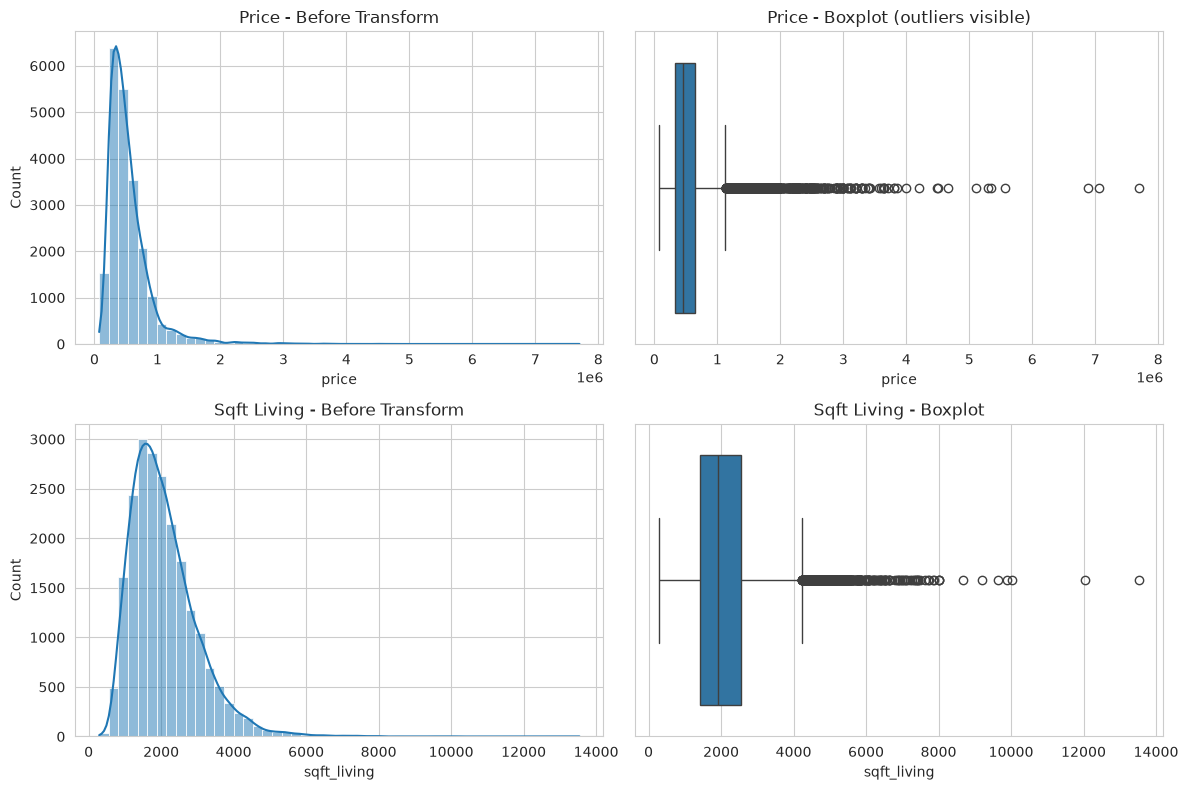

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['price'], bins=50, ax=axes[0,0], kde=True)
axes[0,0].set_title('Price - Before Transform')

sns.boxplot(x=df['price'], ax=axes[0,1])
axes[0,1].set_title('Price - Boxplot (outliers visible)')

sns.histplot(df['sqft_living'], bins=50, ax=axes[1,0], kde=True)
axes[1,0].set_title('Sqft Living - Before Transform')

sns.boxplot(x=df['sqft_living'], ax=axes[1,1])
axes[1,1].set_title('Sqft Living - Boxplot')

plt.tight_layout()
plt.show()

## 3. Log-transform skewed columns
Right-skewed columns get `log1p` (log(1 + x)) applied to reduce skew before scaling.

In [26]:
skewed_cols = ['price', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_lot15']

df_log = df.copy()
for col in skewed_cols:
    df_log[col + '_log'] = np.log1p(df_log[col])

print(df_log[[c + '_log' for c in skewed_cols]].skew().sort_values(ascending=False))

sqft_lot15_log     0.967255
sqft_lot_log       0.962893
price_log          0.428077
sqft_above_log     0.254034
sqft_living_log   -0.034727
dtype: float64


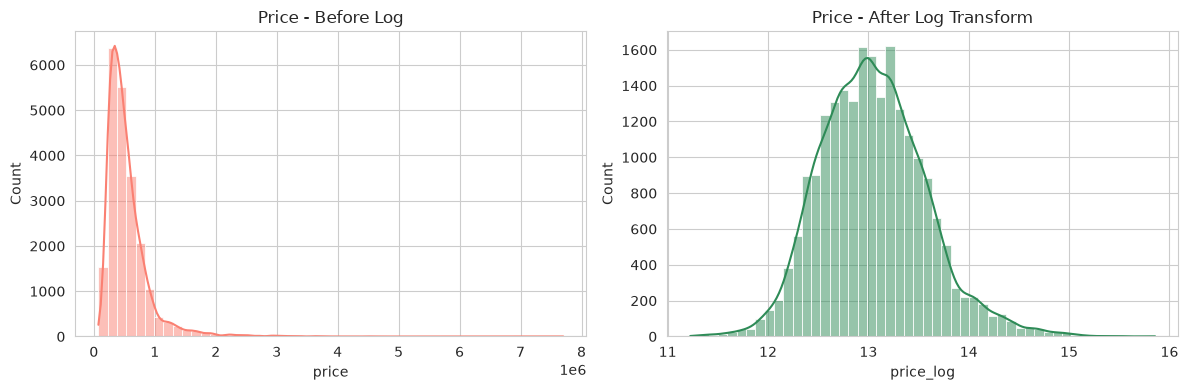

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['price'], bins=50, ax=axes[0], kde=True, color='salmon')
axes[0].set_title('Price - Before Log')

sns.histplot(df_log['price_log'], bins=50, ax=axes[1], kde=True, color='seagreen')
axes[1].set_title('Price - After Log Transform')

plt.tight_layout()
plt.show()

## 4. Apply Scaling
Using **StandardScaler** (mean=0, std=1) as the scaler.

This works across all planned models:
- Tree-based models (CatBoost, LightGBM, XGBoost, Extra Trees, Random Forest) are scale-invariant, so scaling has no effect on them either way.
- TabNet has batch normalization built into its architecture, so it does not strictly require [0,1] MinMax scaling — StandardScaler output works fine.

In [28]:
scale_cols = [
    'price_log', 'bedrooms', 'bathrooms', 'sqft_living_log', 
    'sqft_lot_log', 'floors', 'sqft_above_log', 'sqft_basement', 
    'yr_built', 'sqft_living15', 'sqft_lot15_log', 'lat', 'long'
]

std_scaler = StandardScaler()
df_std = df_log.copy()
df_std[scale_cols] = std_scaler.fit_transform(df_log[scale_cols])

df_std[scale_cols].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
price_log,4.878755e-15,1.000023,-3.460533,5.333331
bedrooms,2.419652e-16,1.000023,-3.624404,31.857929
bathrooms,-1.472832e-16,1.000023,-2.745920,7.641730
sqft_living_log,5.076010e-16,1.000023,-4.422521,4.622685
sqft_lot_log,-2.472253e-16,1.000023,-3.030572,5.903993
floors,-5.260114e-17,1.000023,-0.915427,3.714405
sqft_above_log,1.867340e-15,1.000023,-4.029996,4.104553
sqft_basement,1.841040e-17,1.000023,-0.658681,10.232379
yr_built,1.925202e-15,1.000023,-2.417383,1.497813
sqft_living15,8.021673e-17,1.000023,-2.316325,6.162239


## 5. Before vs After comparison

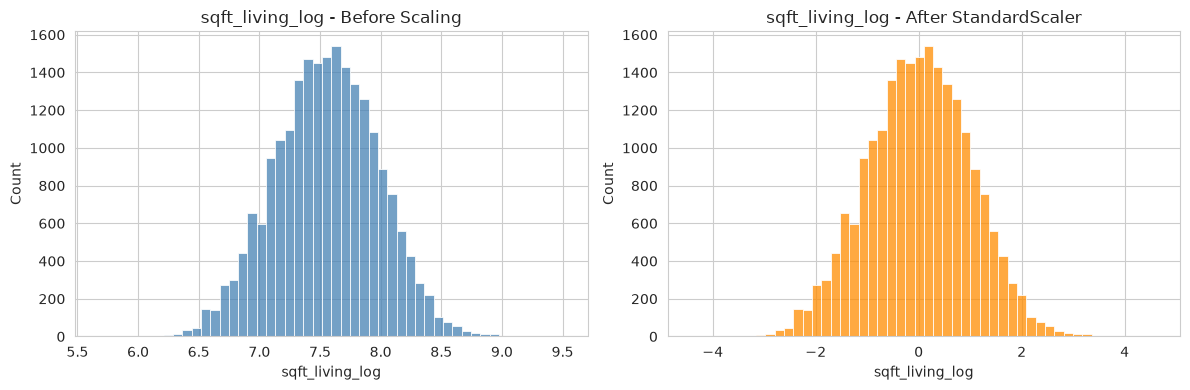

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_log['sqft_living_log'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('sqft_living_log - Before Scaling')

sns.histplot(df_std['sqft_living_log'], bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('sqft_living_log - After StandardScaler')

plt.tight_layout()
plt.show()

## 6. Correlation matrix after scaling
EDA check to confirm relationships between features and the target (`price_log`).

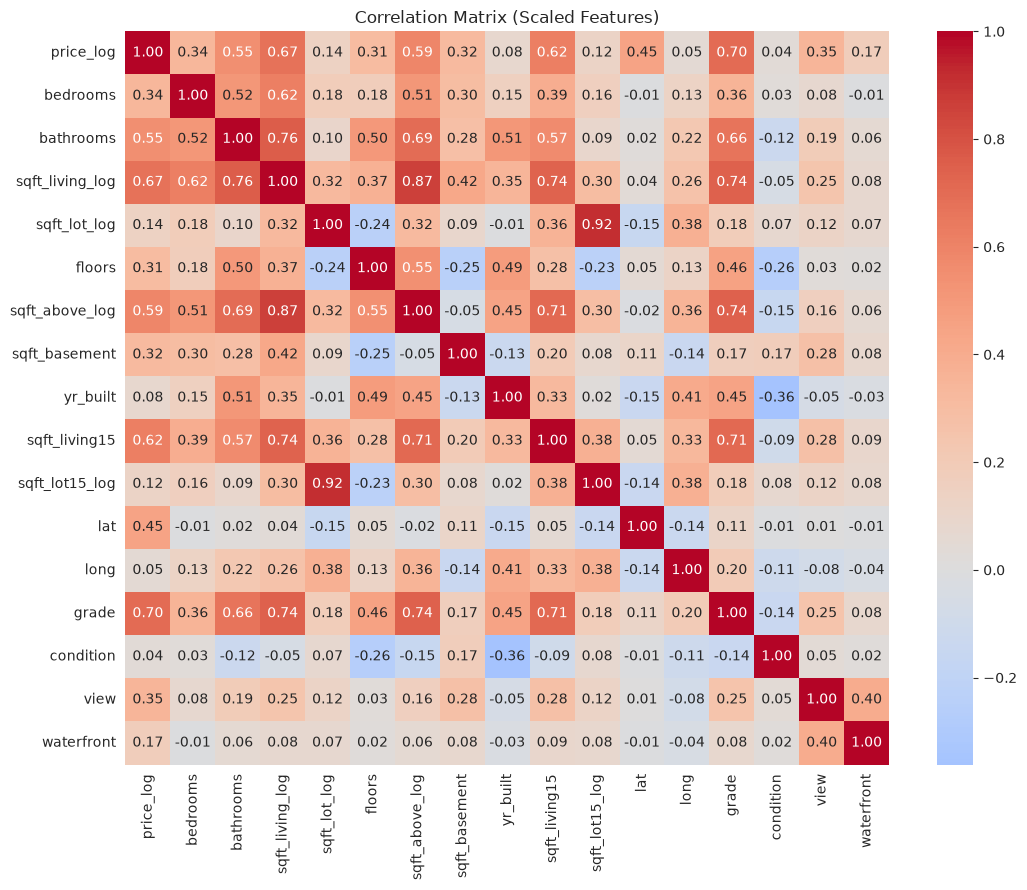

In [30]:
corr_cols = scale_cols + ['grade', 'condition', 'view', 'waterfront']
plt.figure(figsize=(11, 9))
sns.heatmap(df_std[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Scaled Features)')
plt.tight_layout()
plt.show()

## Interpretation
- Log-transform reduced skew in `price`, `sqft_living`, `sqft_lot`, `sqft_above`, `sqft_lot15` close to 0.
- After `StandardScaler`, all numeric features share mean ≈ 0 and std ≈ 1, so no single feature dominates model training due to scale alone.
- `grade` and `sqft_living_log` show the strongest positive correlation with `price_log`, consistent with expectation that construction quality and size drive price.

In [31]:
df_std.to_csv("kc_house_data_processed.csv", index=False)
print("Saved processed dataset: kc_house_data_processed.csv")

Saved processed dataset: kc_house_data_processed.csv
